## Circuit Library
 https://quantum.cloud.ibm.com/docs/en/api/qiskit/circuit_library  

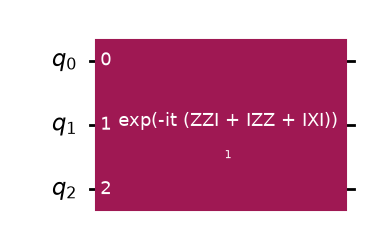

In [1]:
from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import SparsePauliOp

hamiltonian = SparsePauliOp(["ZZI", "IZZ", "IXI"], coeffs=[1, 1, -1])
gate = PauliEvolutionGate(hamiltonian)

circuit = QuantumCircuit(hamiltonian.num_qubits)
circuit.append(gate, circuit.qubits)

circuit.draw("mpl")

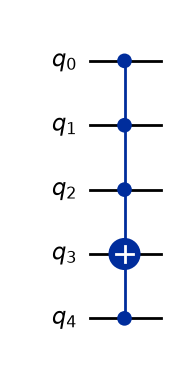

In [2]:
from qiskit.circuit.library import MCXGate
mcx = MCXGate(4)

from qiskit import QuantumCircuit
circuit = QuantumCircuit(5)
circuit.append(mcx, [0, 1, 4, 2, 3])
circuit.draw("mpl")

In [3]:
from qiskit import transpile

small_circuit = QuantumCircuit(5)  # here we have no idle qubits
small_circuit.append(mcx, [0, 1, 4, 2, 3])
small_tqc = transpile(small_circuit, basis_gates=["u", "cx"])
print("No aux:", small_tqc.count_ops())

large_circuit = QuantumCircuit(10)  # now we will have 5 idle qubits
large_circuit.append(mcx, [0, 1, 4, 2, 3])
large_tqc = transpile(large_circuit, basis_gates=["u", "cx"])
print("With aux:", large_tqc.count_ops())

No aux: OrderedDict({'u': 41, 'cx': 36})
With aux: OrderedDict({'u': 25, 'cx': 18})


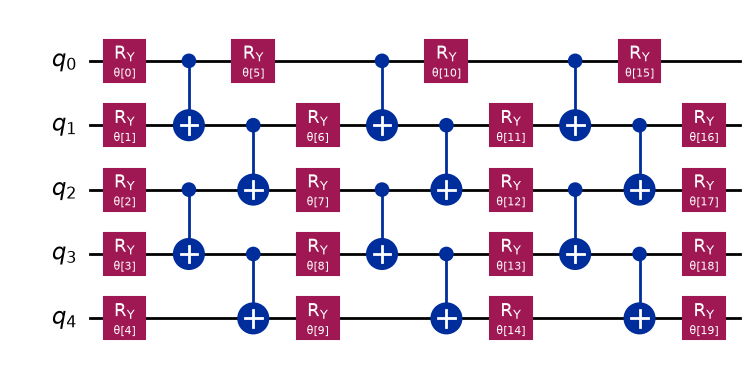

In [4]:
from qiskit.circuit.library import real_amplitudes

ansatz = real_amplitudes(5, entanglement="pairwise")
ansatz.draw("mpl")

### Standard gates

In [5]:
from qiskit.circuit.library import XGate
gate = XGate()
print(gate.to_matrix())             # X gate
print(gate.power(1/2).to_matrix())  # √X gate -- see also the SXGate
print(gate.control(1).to_matrix())  # CX (controlled X) gate

[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
[[0.5+0.5j 0.5-0.5j]
 [0.5-0.5j 0.5+0.5j]]
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]]
